In [1]:
!pip install datasets sentencepiece -q

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import re
import sentencepiece as spm

print(tf.__version__)

2.20.0


In [3]:
dataset = load_dataset("google/code_x_glue_tc_text_to_code")

train_data = dataset['train'].to_pandas()
test_data  = dataset['test'].to_pandas()
val_data   = dataset['validation'].to_pandas()

print(f"train_data shape: {train_data.shape}")
print(f"val_data shape  : {val_data.shape}")
print(f"test_data shape : {test_data.shape}")
print(train_data.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/33.1M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/634k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/526k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

train_data shape: (100000, 3)
val_data shape  : (2000, 3)
test_data shape : (2000, 3)
   id                                                 nl  \
0   0  check if details are parsed . concode_field_se...   
1   1  answer the library file defining the library c...   
2   2  this method deletes index files of the @linkpl...   
3   3  do n't use this . no , really , do n't use thi...   
4   4  force the eventbus from ambarieventpublisher t...   

                                                code  
0         boolean function ( ) { return isParsed ; }  
1         File function ( ) { return libraryFile ; }  
2  void function ( Directory arg0 , Collection < ...  
3  byte [ ] function ( Class < ? > arg0 , Configu...  
4  void function ( Binder arg0 ) { EventBus loc0 ...  


In [4]:
def clean_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def filter_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna(subset=["cleaned_text", "code"])
    mask = (
        df["cleaned_text"].str.strip().str.len().gt(0) &
        df["code"].str.strip().str.len().gt(0)
    )
    return df[mask].reset_index(drop=True)

def preprocess(train_df, val_df, test_df):
    for df in [train_df, val_df, test_df]:
        df["cleaned_text"] = df["nl"].apply(clean_text)

    train_pairs = filter_df(train_df[["cleaned_text", "code"]])
    val_pairs   = filter_df(val_df[["cleaned_text",   "code"]])

    print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_df)}")

    enc_train = train_pairs["cleaned_text"].tolist()
    dec_train = train_pairs["code"].tolist()
    enc_val   = val_pairs["cleaned_text"].tolist()
    dec_val   = val_pairs["code"].tolist()
    enc_test  = test_df["cleaned_text"].tolist()
    test_refs = test_df["code"].tolist()

    return enc_train, dec_train, enc_val, dec_val, enc_test, test_refs

enc_train, dec_train, enc_val, dec_val, enc_test, test_refs = preprocess(train_data, val_data, test_data)

Train: 100000 | Val: 2000 | Test: 2000


In [5]:
with open("encoder_texts.txt", "w", encoding="utf-8") as f:
    for text in enc_train:
        f.write(text + "\n")

with open("decoder_texts.txt", "w", encoding="utf-8") as f:
    for text in dec_train:
        f.write(text + "\n")

PAD_ID = 0
UNK_ID = 1
BOS_ID = 2
EOS_ID = 3

spm_args = dict(
    vocab_size=8000,
    model_type="bpe",
    pad_id=PAD_ID, unk_id=UNK_ID, bos_id=BOS_ID, eos_id=EOS_ID,
    pad_piece="<pad>", unk_piece="<unk>", bos_piece="<sos>", eos_piece="<eos>",
    character_coverage=0.9995,
    shuffle_input_sentence=True,
)

spm.SentencePieceTrainer.train(input="encoder_texts.txt", model_prefix="nl_tokenizer",   **spm_args)
spm.SentencePieceTrainer.train(input="decoder_texts.txt", model_prefix="code_tokenizer", **spm_args)

encoder_sp = spm.SentencePieceProcessor()
encoder_sp.load("nl_tokenizer.model")

decoder_sp = spm.SentencePieceProcessor()
decoder_sp.load("code_tokenizer.model")

print("Encoder sample:", encoder_sp.encode(enc_train[0]))
print("Decoder sample:", decoder_sp.encode(dec_train[0]))

Encoder sample: [549, 362, 5466, 691, 5040, 79, 12, 7965, 48, 7965, 11, 2364, 1456, 12, 7965, 14, 7965, 11, 60, 98, 7107, 12, 7965, 14, 7965, 11, 120, 2131, 12, 7965, 14, 7965, 11, 120, 920, 599, 875, 12, 7965, 14, 7965, 11, 2270, 7569, 773, 12, 7965, 14, 7965, 11, 60, 98, 354, 12, 7965, 14, 7965, 11, 120, 1470, 231, 247, 12, 7965, 14, 7965, 11, 476, 218, 12, 7965, 14, 7965, 11, 265, 144, 548, 111, 12, 7965, 14, 7965, 11, 37, 366, 12, 7965, 14, 7965, 11, 2270, 920, 12, 7965, 14, 7965, 11, 427, 1484, 427, 1484, 12, 7965, 48, 7965, 11, 2364, 1783, 12, 7965, 14, 7965, 11, 265, 144, 709, 111, 12, 7965, 14, 7965, 11, 24, 423, 486, 12, 7965, 14, 7965, 11, 120, 4704, 12, 7965, 14, 7965, 11, 120, 1666, 247, 12, 7965, 14, 7965, 11, 24, 1666, 12, 7965, 14, 7965, 11, 24, 1372, 73, 773, 12, 7965, 14, 7965, 11, 24, 843, 12, 7965, 14, 7965, 11, 24, 3375, 12, 7965, 14, 7965, 11, 120, 2199, 12, 7965, 14, 7965, 11, 24, 843, 1209, 12, 7965, 14, 7965, 11, 37, 737, 12, 7965, 14, 7965, 11, 24, 313, 2279, 1

In [11]:
MAX_ENC_LEN = 50
MAX_DEC_LEN = 200

def encode_and_pad(sp_model, texts, max_len):
    sequences = []
    for text in texts:
        ids = sp_model.encode(text, out_type=int)
        ids = ids[:max_len - 2]
        ids = [BOS_ID] + ids + [EOS_ID]
        sequences.append(ids)
    return tf.keras.preprocessing.sequence.pad_sequences(
        sequences, maxlen=max_len, padding="post", truncating="post", value=PAD_ID
    )

enc_train_seq = encode_and_pad(encoder_sp, enc_train, MAX_ENC_LEN)
enc_val_seq   = encode_and_pad(encoder_sp, enc_val,   MAX_ENC_LEN)
enc_test_seq  = encode_and_pad(encoder_sp, enc_test,  MAX_ENC_LEN)

dec_train_seq = encode_and_pad(decoder_sp, dec_train, MAX_DEC_LEN)
dec_val_seq   = encode_and_pad(decoder_sp, dec_val,   MAX_DEC_LEN)

dec_in_train  = dec_train_seq[:, :-1]
dec_tgt_train = dec_train_seq[:, 1:]

dec_in_val    = dec_val_seq[:, :-1]
dec_tgt_val   = dec_val_seq[:, 1:]

ENC_VOCAB_SIZE = encoder_sp.get_piece_size()
DEC_VOCAB_SIZE = decoder_sp.get_piece_size()
EMBEDDING_DIM  = 256

print(f"enc_train_seq  : {enc_train_seq.shape}")
print(f"dec_in_train   : {dec_in_train.shape}")
print(f"dec_tgt_train  : {dec_tgt_train.shape}")
print(f"ENC_VOCAB_SIZE : {ENC_VOCAB_SIZE}")
print(f"DEC_VOCAB_SIZE : {DEC_VOCAB_SIZE}")

enc_train_seq  : (100000, 50)
dec_in_train   : (100000, 199)
dec_tgt_train  : (100000, 199)
ENC_VOCAB_SIZE : 8000
DEC_VOCAB_SIZE : 8000


In [12]:
def Positional_Encoding(max_len, embedding_dim):
    positions = np.arange(max_len)[:, np.newaxis]
    dims      = np.arange(embedding_dim)[np.newaxis, :]
    angles    = positions / np.power(10000, (2 * (dims // 2)) / embedding_dim)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

print("Encoder PE shape:", Positional_Encoding(MAX_ENC_LEN,     EMBEDDING_DIM).shape)
print("Decoder PE shape:", Positional_Encoding(MAX_DEC_LEN - 1, EMBEDDING_DIM).shape)

Encoder PE shape: (1, 50, 256)
Decoder PE shape: (1, 199, 256)


In [23]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.d_model   = d_model
        self.num_heads = num_heads
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)

    def call(self, q, k, v, mask=None):
        return self.att(q, k, v, attention_mask=mask)

    def get_config(self):
        config = super().get_config()
        config.update({"d_model": self.d_model, "num_heads": self.num_heads})
        return config


class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model; self.num_heads = num_heads; self.dff = dff; self.rate = rate
        self.attn  = MultiHeadAttention(d_model, num_heads)
        self.ffn   = tf.keras.Sequential([tf.keras.layers.Dense(dff, activation="gelu"), tf.keras.layers.Dense(d_model)])
        self.ln1   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training=False, mask=None):
        x = self.ln1(x + self.drop1(self.attn(x, x, x, mask=mask), training=training))
        x = self.ln2(x + self.drop2(self.ffn(x), training=training))
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"d_model": self.d_model, "num_heads": self.num_heads, "dff": self.dff, "rate": self.rate})
        return config


class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model; self.num_heads = num_heads; self.dff = dff; self.rate = rate
        self.masked_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn  = MultiHeadAttention(d_model, num_heads)
        self.ffn   = tf.keras.Sequential([tf.keras.layers.Dense(dff, activation="gelu"), tf.keras.layers.Dense(d_model)])
        self.ln1   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln3   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = tf.keras.layers.Dropout(rate)
        self.drop2 = tf.keras.layers.Dropout(rate)
        self.drop3 = tf.keras.layers.Dropout(rate)

    def call(self, x, enc_out, training=False, look_ahead_mask=None, padding_mask=None):
        x = self.ln1(x + self.drop1(self.masked_attn(x, x, x, mask=look_ahead_mask), training=training))
        x = self.ln2(x + self.drop2(self.cross_attn(x, enc_out, enc_out, mask=padding_mask), training=training))
        x = self.ln3(x + self.drop3(self.ffn(x), training=training))
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"d_model": self.d_model, "num_heads": self.num_heads, "dff": self.dff, "rate": self.rate})
        return config


class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, max_len, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.num_layers = num_layers; self.d_model = d_model; self.num_heads = num_heads
        self.dff = dff; self.vocab_size = vocab_size; self.max_len = max_len; self.rate = rate
        self.embedding    = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = Positional_Encoding(max_len, d_model)
        self.enc_layers   = [EncoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]
        self.dropout      = tf.keras.layers.Dropout(rate)

    def call(self, x, training=False, mask=None):
        x  = self.embedding(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :tf.shape(x)[1], :]
        x  = self.dropout(x, training=training)
        for layer in self.enc_layers:
            x = layer(x, training=training, mask=mask)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"num_layers": self.num_layers, "d_model": self.d_model, "num_heads": self.num_heads,
                       "dff": self.dff, "vocab_size": self.vocab_size, "max_len": self.max_len, "rate": self.rate})
        return config


class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, max_len, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.num_layers = num_layers; self.d_model = d_model; self.num_heads = num_heads
        self.dff = dff; self.vocab_size = vocab_size; self.max_len = max_len; self.rate = rate
        self.embedding    = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_decoding = Positional_Encoding(max_len - 1, d_model)
        self.dec_layers   = [DecoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]
        self.dropout      = tf.keras.layers.Dropout(rate)

    def call(self, x, enc_out, training=False, look_ahead_mask=None, padding_mask=None):
        x  = self.embedding(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_decoding[:, :tf.shape(x)[1], :]
        x  = self.dropout(x, training=training)
        for layer in self.dec_layers:
            x = layer(x, enc_out, training=training, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"num_layers": self.num_layers, "d_model": self.d_model, "num_heads": self.num_heads,
                       "dff": self.dff, "vocab_size": self.vocab_size, "max_len": self.max_len, "rate": self.rate})
        return config


class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, max_enc_len, max_dec_len, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.num_layers = num_layers; self.d_model = d_model; self.num_heads = num_heads
        self.dff = dff; self.input_vocab_size = input_vocab_size; self.target_vocab_size = target_vocab_size
        self.max_enc_len = max_enc_len; self.max_dec_len = max_dec_len; self.rate = rate
        self.encoder     = Encoder(num_layers, d_model, num_heads, dff, input_vocab_size,  max_enc_len, rate)
        self.decoder     = Decoder(num_layers, d_model, num_heads, dff, target_vocab_size, max_dec_len, rate)
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def create_masks(self, inp, tar):
        enc_mask     = tf.math.not_equal(inp, 0)[:, tf.newaxis, :]
        tar_len      = tf.shape(tar)[1]
        causal_mask  = tf.linalg.band_part(tf.ones((tar_len, tar_len), dtype=tf.bool), -1, 0)[tf.newaxis, :, :]
        dec_pad_mask = tf.math.not_equal(tar, 0)[:, tf.newaxis, :]
        combined     = dec_pad_mask & causal_mask
        return enc_mask, combined, enc_mask

    def call(self, inputs, training=False):
        inp, tar = inputs
        enc_mask, combined_mask, dec_mask = self.create_masks(inp, tar)
        enc_out = self.encoder(inp, training=training, mask=enc_mask)
        dec_out = self.decoder(tar, enc_out, training=training, look_ahead_mask=combined_mask, padding_mask=dec_mask)
        return self.final_layer(dec_out)

    def get_config(self):
        config = super().get_config()
        config.update({"num_layers": self.num_layers, "d_model": self.d_model, "num_heads": self.num_heads,
                       "dff": self.dff, "input_vocab_size": self.input_vocab_size,
                       "target_vocab_size": self.target_vocab_size, "max_enc_len": self.max_enc_len,
                       "max_dec_len": self.max_dec_len, "rate": self.rate})
        return config

In [24]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(tf.math.rsqrt(step), step * (self.warmup_steps ** -1.5))

    def get_config(self):
        return {"d_model": int(self.d_model.numpy()), "warmup_steps": self.warmup_steps}


loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def masked_loss(y_true, y_pred):
    loss = loss_fn(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    pred  = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    true  = tf.cast(y_true, tf.int32)
    mask  = tf.cast(tf.not_equal(true, PAD_ID), tf.float32)
    return tf.reduce_sum(tf.cast(tf.equal(pred, true), tf.float32) * mask) / tf.reduce_sum(mask)


transformer = Transformer(
    num_layers        = 4,
    d_model           = EMBEDDING_DIM,
    num_heads         = 8,
    dff               = 1024,
    input_vocab_size  = ENC_VOCAB_SIZE,
    target_vocab_size = DEC_VOCAB_SIZE,
    max_enc_len       = MAX_ENC_LEN,
    max_dec_len       = MAX_DEC_LEN,
    rate              = 0.1
)


transformer.compile(
    optimizer = tf.keras.optimizers.Adam(CustomSchedule(EMBEDDING_DIM), beta_1=0.9, beta_2=0.98, epsilon=1e-9),
    loss      = masked_loss,
    metrics   = [masked_accuracy]
)

dummy_enc = tf.zeros((1, MAX_ENC_LEN),     dtype=tf.int32)
dummy_dec = tf.zeros((1, MAX_DEC_LEN - 1), dtype=tf.int32)
print("Output shape:", transformer((dummy_enc, dummy_dec), training=False).shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention_96' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_16' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'multi_head_attention_98' (of type MultiHeadAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the m

Output shape: (1, 199, 8000)


In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint("best_transformer.keras", monitor="val_loss", save_best_only=True, verbose=1),

]

history = transformer.fit(
    x               = [enc_train_seq, dec_in_train],
    y               = dec_tgt_train,
    validation_data = ([enc_val_seq, dec_in_val], dec_tgt_val),
    batch_size      = 64,
    epochs          = 30,
    callbacks       = callbacks,
)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - loss: 5.2897 - masked_accuracy: 0.3812
Epoch 1: val_loss improved from None to 2.39325, saving model to best_transformer.keras

Epoch 1: finished saving model to best_transformer.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 487s 278ms/step - loss: 3.4946 - masked_accuracy: 0.5181 - val_loss: 2.3932 - val_masked_accuracy: 0.5917
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - loss: 1.9608 - masked_accuracy: 0.6555
Epoch 2: val_loss improved from 2.39325 to 1.99618, saving model to best_transformer.keras

Epoch 2: finished saving model to best_transformer.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 399s 255ms/step - loss: 1.8482 - masked_accuracy: 0.6690 - val_loss: 1.9962 - val_masked_accuracy: 0.6348
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - loss: 1.5224 - masked_accuracy: 0.7060
Epoch 3: val_loss improved from 1.99618 to 1.84465, saving model to best_transformer.keras

Epoch 3: finished saving model to best_transform

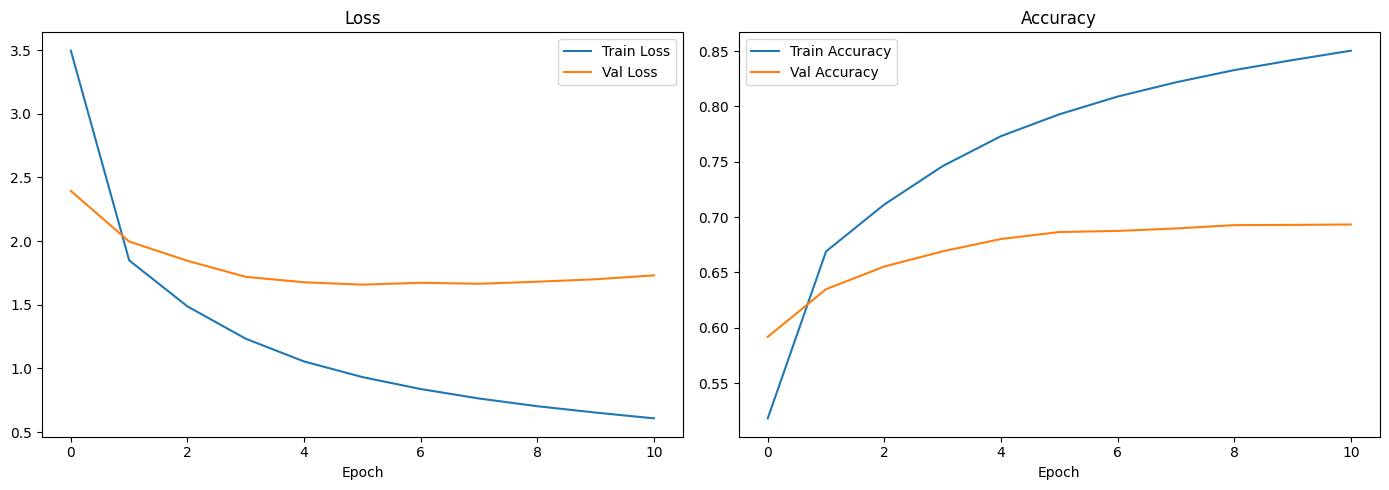

In [26]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss"); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["masked_accuracy"],     label="Train Accuracy")
plt.plot(history.history["val_masked_accuracy"], label="Val Accuracy")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [27]:
def generate_code(nl_text, max_len=200):
    enc_seq = encode_and_pad(encoder_sp, [clean_text(nl_text)], MAX_ENC_LEN)
    dec_seq = np.array([[BOS_ID] + [PAD_ID] * (MAX_DEC_LEN - 2)], dtype=np.int32)

    for i in range(1, max_len):
        preds     = transformer((enc_seq, dec_seq[:, :-1]), training=False)
        next_id   = int(tf.argmax(preds[0, i - 1, :]))
        if next_id == EOS_ID:
            break
        dec_seq[0, i] = next_id

    tokens = dec_seq[0, 1:].tolist()
    tokens = [t for t in tokens if t not in (PAD_ID, EOS_ID)]
    return decoder_sp.decode(tokens)

print(generate_code(enc_test[0]))
print("Reference:", test_refs[0])

void function ( ) { for ( Node loc0 : f_coin . getAll ( ) ) { loc0 . generate ( ) ; } }
Reference: 
